# **WEEK 4**

# *Task 02 Ensemble Learning*

In [1]:
!pip install xgboost

# STEP 1 - IMPORT THE LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Step 2 — Load the Titanic dataset

In [4]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 3 — Inspect the dataset

In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Step 4 — Prepare the features and target

## Feature Selection

The selected features include passenger class, gender, age, number of siblings/spouses, number of parents/children, fare, and port of embarkation. These features provide useful information for predicting passenger survival.

In [8]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


# Step 5 — Split the data

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (712, 7)
Testing set: (179, 7)


# Step 6 — Handle categorical and numerical features

In [10]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

In [11]:
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Step 7 — Train the original Logistic Regression model

## Baseline Model — Logistic Regression

Logistic Regression is used as the baseline single machine learning model. Its performance will be compared with Random Forest and XGBoost to determine whether ensemble learning provides better predictive performance.

In [12]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

In [13]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression
Accuracy : 0.8044692737430168
Precision: 0.7931034482758621
Recall   : 0.6666666666666666
F1 Score : 0.7244094488188977


# Step 8 — Train Random Forest

## Random Forest Classifier

Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions. For classification, the final prediction is generally based on the majority vote of the individual trees.

In [20]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [21]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [22]:
y_pred_rf = rf_model.predict(X_test)

In [23]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)

print("Random Forest")
print("--------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest
--------------------
Accuracy : 0.8156
Precision: 0.8103
Recall   : 0.6812
F1 Score : 0.7402


# Step 9 — XGBoost Classifier

In [24]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [25]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('classifier',
                 XGBClassifi...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [26]:
y_pred_xgb = xgb_model.predict(X_test)

In [27]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_test, y_pred_xgb, zero_division=0)
xgb_f1 = f1_score(y_test, y_pred_xgb, zero_division=0)

print("XGBoost")
print("--------------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

XGBoost
--------------------
Accuracy : 0.7933
Precision: 0.7963
Recall   : 0.6232
F1 Score : 0.6992


# Step 10 — Compare All Three Models

## Model Performance Comparison

The three classification models are compared using Accuracy, Precision, Recall, and F1-score. Logistic Regression is used as the baseline model, while Random Forest and XGBoost represent ensemble learning approaches.

In [28]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8045,0.7931,0.6667,0.7244
1,Random Forest,0.8156,0.8103,0.6812,0.7402
2,XGBoost,0.7933,0.7963,0.6232,0.6992


# Step 11 — The Best Model

In [29]:
best_model = comparison.loc[
    comparison["F1 Score"].idxmax()
]

print("Best Model based on F1 Score:")
print(best_model["Model"])
print(f"F1 Score: {best_model['F1 Score']:.4f}")

Best Model based on F1 Score:
Random Forest
F1 Score: 0.7402


# Step 12 — Random Forest Feature Importance

In [30]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

rf_feature_names = rf_preprocessor.get_feature_names_out()

rf_importance = rf_classifier.feature_importances_

In [31]:
rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importance
}).sort_values(
    by="Importance",
    ascending=False
)

rf_importance_df

,Feature,Importance
4,num__Fare,0.258759
1,num__Age,0.243951
6,cat__Sex_male,0.158605
5,cat__Sex_female,0.131465
0,num__Pclass,0.085362
2,num__SibSp,0.046857
3,num__Parch,0.040157
9,cat__Embarked_S,0.014058
7,cat__Embarked_C,0.012751
8,cat__Embarked_Q,0.008034


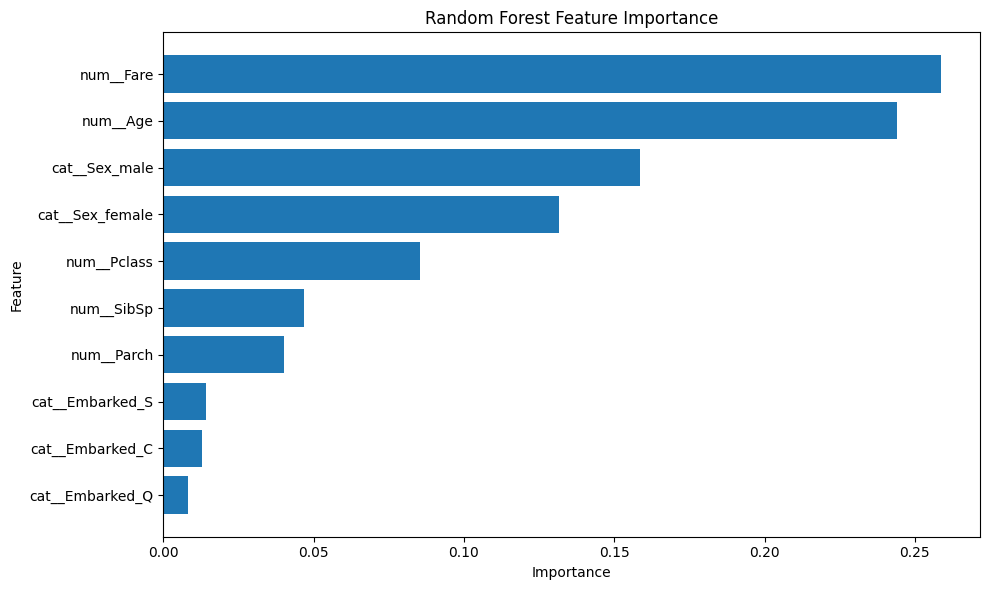

In [32]:
plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance_df["Feature"],
    rf_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Step 13 — XGBoost Feature Importance

In [33]:
xgb_preprocessor = xgb_model.named_steps["preprocessor"]
xgb_classifier = xgb_model.named_steps["classifier"]

xgb_feature_names = xgb_preprocessor.get_feature_names_out()

xgb_importance = xgb_classifier.feature_importances_

In [34]:
xgb_importance_df = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_importance
}).sort_values(
    by="Importance",
    ascending=False
)

xgb_importance_df

,Feature,Importance
5,cat__Sex_female,0.598843
0,num__Pclass,0.173689
9,cat__Embarked_S,0.059557
1,num__Age,0.047507
2,num__SibSp,0.044934
4,num__Fare,0.042587
7,cat__Embarked_C,0.020037
3,num__Parch,0.011187
8,cat__Embarked_Q,0.001658
6,cat__Sex_male,0.000000


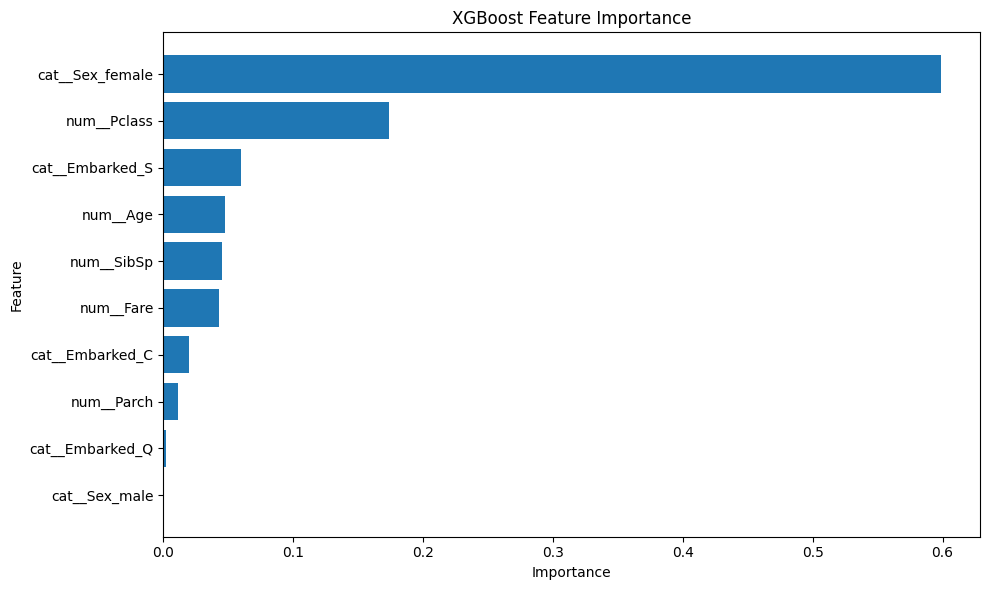

In [35]:
plt.figure(figsize=(10, 6))

plt.barh(
    xgb_importance_df["Feature"],
    xgb_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Step 14 — Display Top 5 Features

In [36]:
print("Top 5 Random Forest Features:")
display(rf_importance_df.head(5))

print("\nTop 5 XGBoost Features:")
display(xgb_importance_df.head(5))

Top 5 Random Forest Features:


,Feature,Importance
4,num__Fare,0.258759
1,num__Age,0.243951
6,cat__Sex_male,0.158605
5,cat__Sex_female,0.131465
0,num__Pclass,0.085362



Top 5 XGBoost Features:


,Feature,Importance
5,cat__Sex_female,0.598843
0,num__Pclass,0.173689
9,cat__Embarked_S,0.059557
1,num__Age,0.047507
2,num__SibSp,0.044934


## Random Forest vs XGBoost

Random Forest builds multiple decision trees independently and combines their predictions through voting for classification. XGBoost builds decision trees sequentially, with each new tree attempting to correct the errors made by previous trees. Random Forest mainly reduces variance by averaging many independent trees, while XGBoost uses boosting to gradually improve the model. Both ensemble methods can capture complex and nonlinear patterns that may be difficult for a single Logistic Regression model to learn.

## Feature Importance Comparison

The feature importance plots show which variables contributed most to the predictions made by Random Forest and XGBoost. Although both models may identify similar important features, their importance rankings can differ because they use different ensemble strategies. Comparing these rankings helps us understand which passenger characteristics are consistently useful for predicting Titanic survival.

## Results Analysis

Random Forest achieved the best overall performance, with an accuracy of 81.56% and an F1-score of 74.02%. It slightly outperformed Logistic Regression, which achieved an accuracy of 80.45% and an F1-score of 72.44%. XGBoost achieved the lowest performance among the three models, with an accuracy of 79.33% and an F1-score of 69.92%. This shows that ensemble methods do not always guarantee better performance, as the effectiveness of a model depends on the dataset and its hyperparameters.

# Step 15 — Feature Importance Comparison

In [37]:
print("Top 5 Random Forest Features:")
display(rf_importance_df.head(5))

print("\nTop 5 XGBoost Features:")
display(xgb_importance_df.head(5))

Top 5 Random Forest Features:


,Feature,Importance
4,num__Fare,0.258759
1,num__Age,0.243951
6,cat__Sex_male,0.158605
5,cat__Sex_female,0.131465
0,num__Pclass,0.085362



Top 5 XGBoost Features:


,Feature,Importance
5,cat__Sex_female,0.598843
0,num__Pclass,0.173689
9,cat__Embarked_S,0.059557
1,num__Age,0.047507
2,num__SibSp,0.044934


#CONCLUSION

Random Forest performed best, while XGBoost performed worse than both Random Forest and Logistic Regression on this Titanic dataset.